# EDA

## Team norms:
- Don't push directly to main branch, always branch + make a merge request
- Add helpfull notes and insights in markdown cells to help guide the reader
- Keep all imports at the top of the notebook, don't let random imports dangle all over the notebook (AI LOVES importing pandas over and over again lol)
- Try to have EDA tell a story and follow a logical flow

In [2]:
# PLEASE do not add duplicates to this cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import random
import re
from urllib.parse import unquote
from IPython.display import display

## Load tabular data and clean

In [3]:
df = pd.read_csv("../data/npc.csv")

# Data cleaning

# Gender: collapse anything besides Male/Female to Other
df["Gender"] = df["Gender"].apply(lambda x: x if x in ("Male", "Female") else "Other")

# Members: treat "? (edit)" as Yes
df["Members"] = df["Members"].replace("? (edit)", "Yes")

# Race → Class, with value normalization
df = df.rename(columns={"Race": "Class"})
df["Class"] = df["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf"
})

## Coverage

In [6]:
# counts and missing values
print(df.shape)

coverage = pd.DataFrame({
    "n_present": df.notna().sum(),
    "pct_present": (df.notna().mean() * 100).round(1)
}).sort_values("pct_present")
coverage

(4443, 23)


,n_present,pct_present
Respawn time,2,0.0
Size,7,0.2
Also called,39,0.9
Combat level,225,5.1
Removal,460,10.4
Shop,563,12.7
Quest,1450,32.6
lon,3102,69.8
lat,3102,69.8
Options,3340,75.2


## Class, Gender, Members (free-to-play or pay-to-play) counts

In [4]:
df['Class'].value_counts().head(15)

Class
Human         2212
Dwarf          255
Elf            150
Gnome          142
Ghost           79
Vampyre         65
Cat             56
Monkey          45
Bird            41
Dorgeshuun      40
Troll           39
Goblin          37
Dog             30
Demon           29
Undead          28
Name: count, dtype: int64

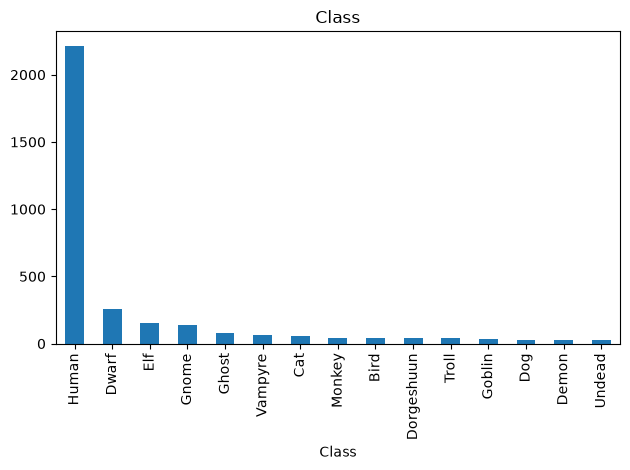

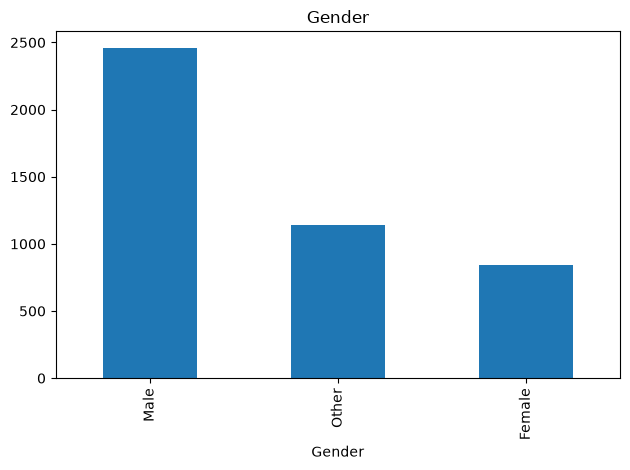

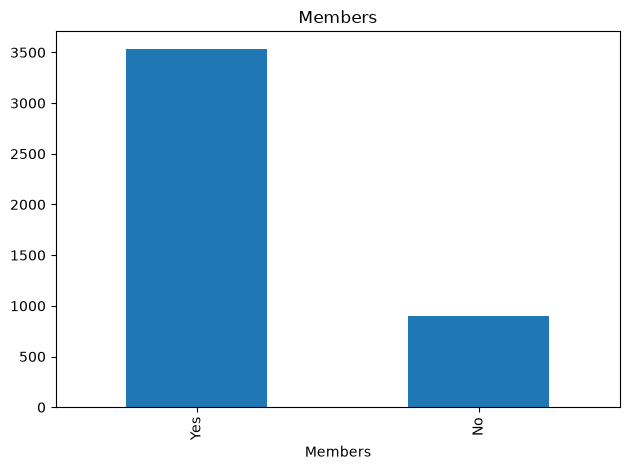

In [10]:
# Univariate analysis
for col in ["Class", "Gender", "Members"]:
    df[col].value_counts().head(15).plot(kind="bar", title=col)
    plt.tight_layout()
    plt.savefig(f"../img/univariate_{col}.png")
    plt.show()

## Location

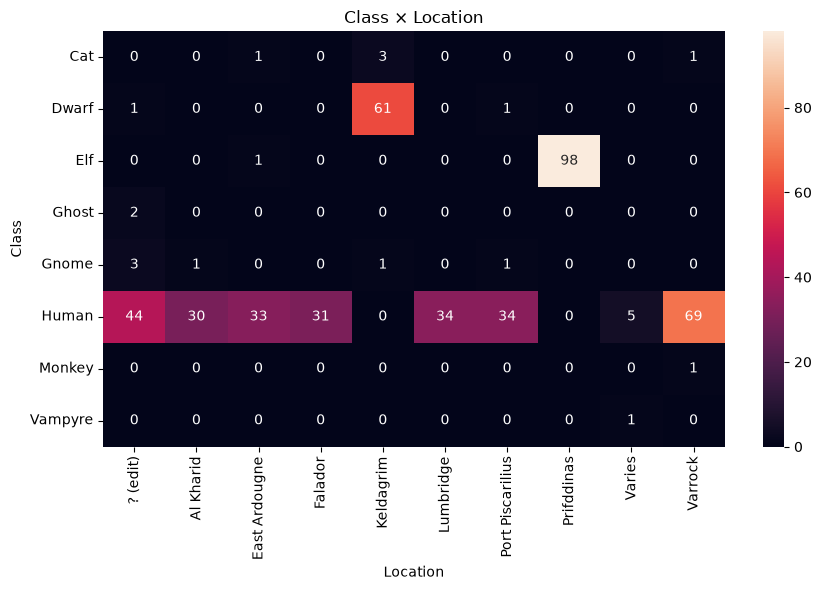

In [ ]:
# Bivariate analysis (class x location)
top_classes = df["Class"].value_counts().head(8).index
top_locs = df["Location"].value_counts().head(10).index

pivot_location = pd.crosstab(
    df[df["Class"].isin(top_classes)]["Class"],
    df[df["Class"].isin(top_classes) & df["Location"].isin(top_locs)]["Location"]
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_location, annot=True, fmt="d", cmap="rocket")
plt.title("Class × Location")
plt.tight_layout()
plt.savefig("../img/bivariate_class_location.png")
plt.show()

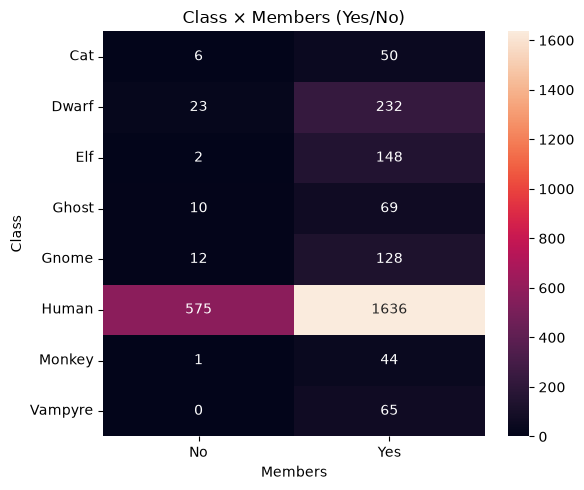

In [12]:
# Bivariate analysis (class x members)
pivot_members = pd.crosstab(
    df[df["Class"].isin(top_classes)]["Class"],
    df[df["Class"].isin(top_classes)]["Members"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_members, annot=True, fmt="d", cmap="rocket")
plt.title("Class × Members (Yes/No)")
plt.tight_layout()
plt.savefig("../img/bivariate_class_members.png")
plt.show()

# Image stuff

## Dimensions

corrupt/unreadable: 0
total readable: 4193


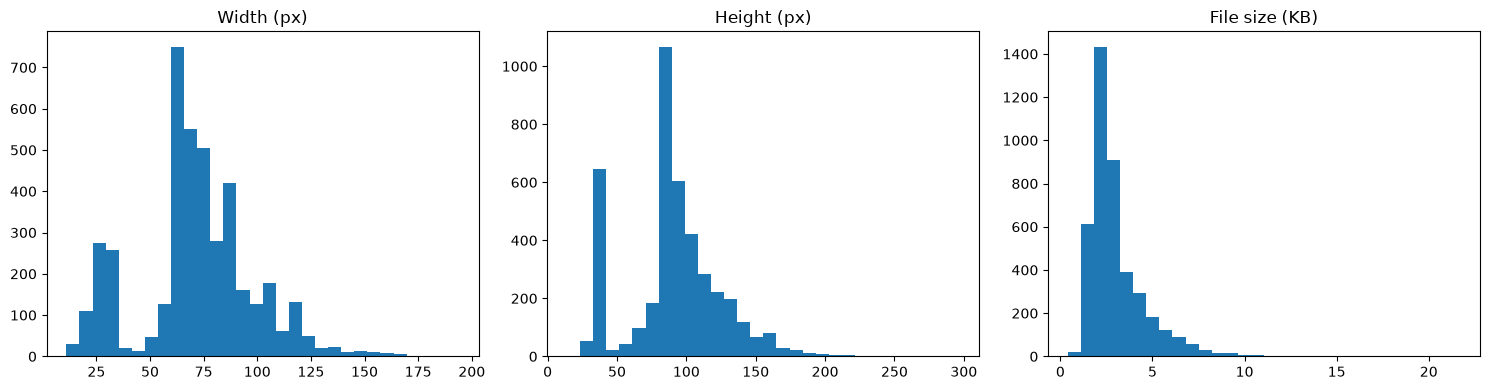

In [ ]:
# Check image existence and dimensions (histogram of file sizes, widths, heights)
sizes, widths, heights, corrupt = [], [], [], []
for f in os.listdir("../data/chatheads"):
    fp = f"../data/chatheads/{f}"
    try:
        with Image.open(fp) as im:
            w, h = im.size
            widths.append(w)
            heights.append(h)
            sizes.append(os.path.getsize(fp))
    except Exception:
        corrupt.append(f)

print(f"corrupt/unreadable: {len(corrupt)}")
print(f"total readable: {len(widths)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=30); axes[0].set_title("Width (px)")
axes[1].hist(heights, bins=30); axes[1].set_title("Height (px)")
axes[2].hist([s / 1024 for s in sizes], bins=30); axes[2].set_title("File size (KB)")
plt.tight_layout()
plt.savefig("../img/image_dim_size_histograms.png")
plt.show()

## Summary grid

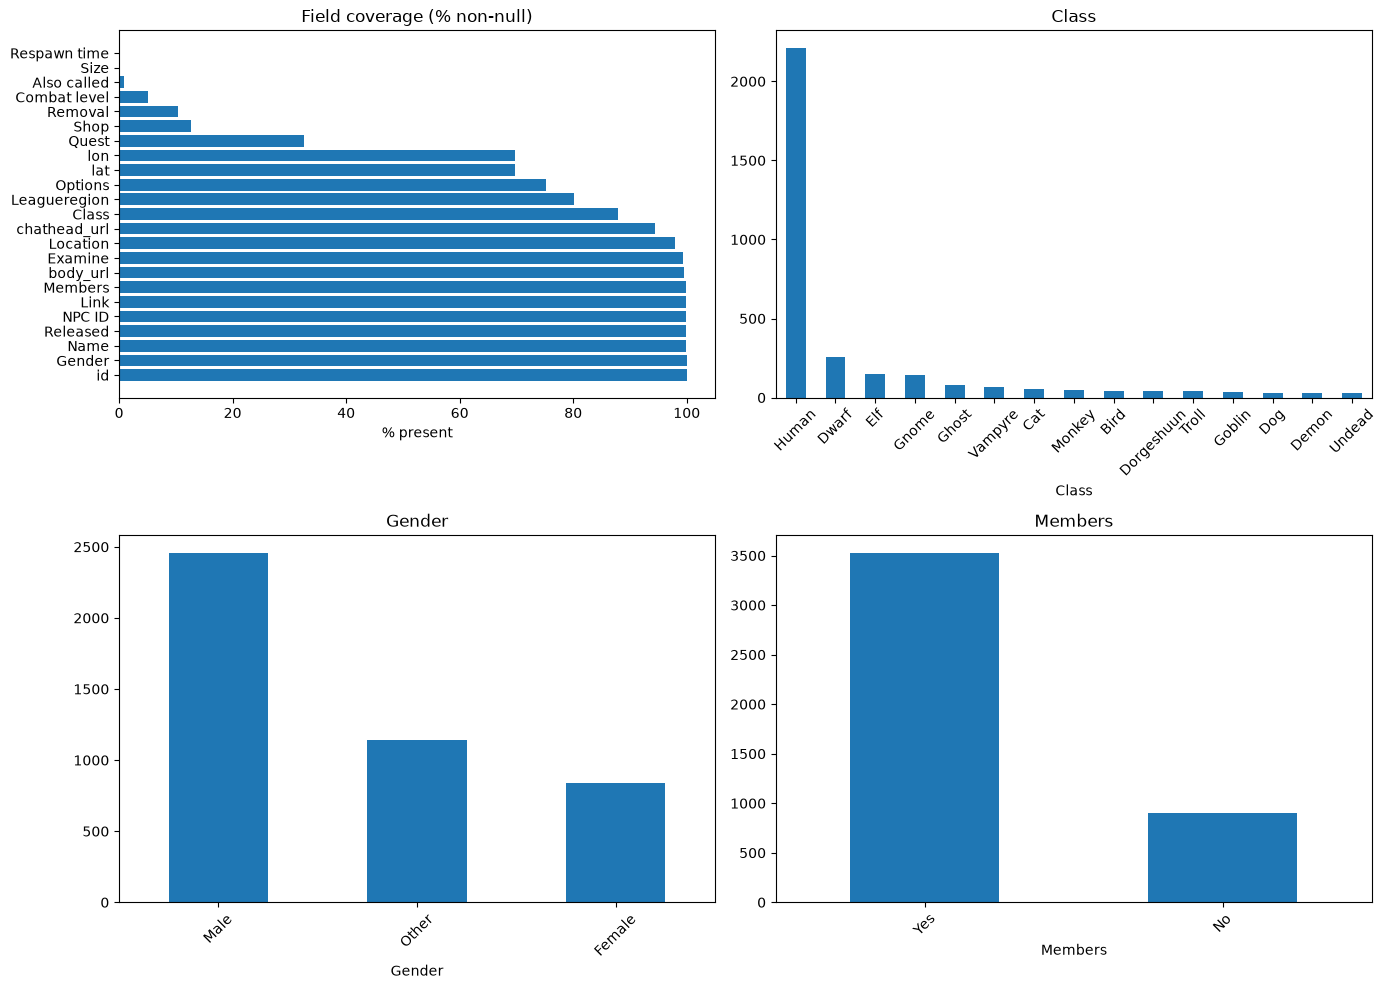

In [ ]:
# coverage + univariate summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: coverage table as a horizontal bar chart (easier to read than a raw table in a figure)
axes[0, 0].barh(coverage.index[::-1], coverage["pct_present"][::-1])
axes[0, 0].set_title("Field coverage (% non-null)")
axes[0, 0].set_xlabel("% present")

# Top-right, bottom-left, bottom-right: the three univariate categoricals
cols = ["Class", "Gender", "Members"]
positions = [(0, 1), (1, 0), (1, 1)]
for col, (r, c) in zip(cols, positions):
    df[col].value_counts().head(15).plot(kind="bar", ax=axes[r, c], title=col)
    axes[r, c].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../img/eda_summary_combined.png", dpi=150)
plt.show()

## View the images

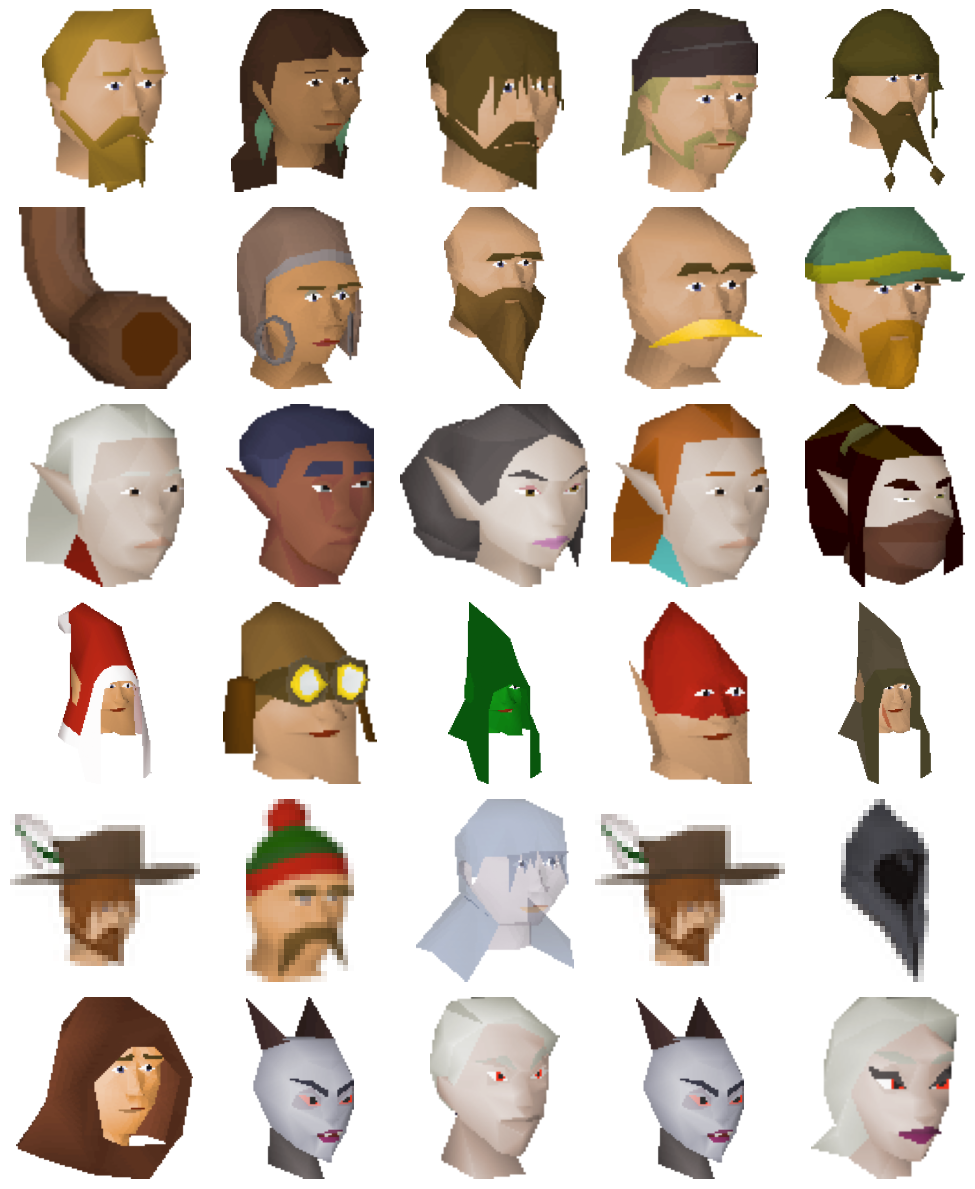

In [22]:
# Grid per class
df["has_chathead"] = df["chathead_url"].notna()

top_classes = df["Class"].value_counts().head(6).index.tolist()
n_samples = 5

fig, axes = plt.subplots(len(top_classes), n_samples, figsize=(n_samples * 2, len(top_classes) * 2))

for row, cls in enumerate(top_classes):
    cls_df = df[(df["Class"] == cls) & (df["has_chathead"])]
    sample_ids = cls_df["id"].sample(min(n_samples, len(cls_df)), random_state=42).tolist()
    for col, npc_id in enumerate(sample_ids):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/chatheads/{npc_id}.png")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, rotation=0, labelpad=40)

plt.tight_layout()
plt.savefig("../img/sample_grid_by_class.png")
plt.show()

## QA: we have a data quality issue

When scraping chathead images, our scraper searched for `_chathead.png` across the entire page rather than scoping the search to the infobox. Many NPC pages actually don't have a chathead at all. So our approach worked perfectly fine for NPCs that **do** have a chat head, but grabbed something random for NPCs that don't. It basically found very small images at the bottom of the page in the navigation footer. It then grabbed the first image it could find, which is both (1) not of the NPC in question and (2) very, very small and low-res. 

Example: https://oldschool.runescape.wiki/w/Agitated_bees

Camille caught this by auditing mismatches between the NPC's name and the filename stem of the chathead URL. Oliver then did some spot-checks (see below)

Note: the full body images are fine. The scraper was more properly scoped to just the infobox for those images. Also NPCs almost always have a body image, even if no chathead. 

We can fix the chat head issue by re-running scraping for the chatheads, but this time restricting the search to `table.infobox-npc`, and re-downloading the corrected images.

Note: Camille surfaced 3 categories of "mismatches". Two were actually perfectly fine:
- URL-encoded special characters (ex: 50%25_Luke, A%27abla - the name and image match just fine, the URL is just percent-encoded). Fixed by adding unquote().
- Disambiguation suffixes (Academic_(1), Alan_(Farming_Guild)). The wiki appends extra context to the filename, so the NPC name doesn't match perfectly, but still the correct image.


**I will fix the scraper and rerun in a differente notebook, but below see some more context**

In [ ]:
# Check for mismatches between Name and chathead_url filename
def extract_filename_stem(url):
    if pd.isna(url):
        return None
    # handle thumbnail paths like .../thumb/Foo_chathead.png/23px-Foo_chathead.png
    # the real subject name is usually in the /thumb/ segment, not the final 23px- one
    m = re.search(r'/thumb/([^/]+?)_chathead\.png', url)
    if m:
        return unquote(m.group(1))
    m = re.search(r'/([^/]+?)_chathead\.png', url)
    if m:
        return unquote(m.group(1))
    return None

def normalize(s):
    if pd.isna(s):
        return None
    return re.sub(r'[^a-z0-9]', '', s.lower())

df["chathead_filename_stem"] = df["chathead_url"].apply(extract_filename_stem)
df["name_norm"] = df["Name"].apply(normalize)
df["filename_norm"] = df["chathead_filename_stem"].apply(normalize)

# genuine mismatch: filename shares NO words with name (catches wrong-NPC images, ignores disambiguation suffixes)
def shares_any_word(name, filename):
    if pd.isna(name) or pd.isna(filename):
        return False
    name_words = set(re.sub(r'[^a-z0-9]', ' ', name.lower()).split())
    filename_words = set(re.sub(r'[^a-z0-9]', ' ', filename.lower()).split())
    return bool(name_words & filename_words)

df["genuine_mismatch"] = (
    df["chathead_filename_stem"].notna()
    & df["Name"].notna()
    & ~df.apply(lambda r: shares_any_word(r["Name"], r["chathead_filename_stem"]), axis=1)
)

# has_chathead: True only if chathead_url exists and isn't a genuine mismatch
df["has_chathead"] = df["chathead_url"].notna() & ~df["genuine_mismatch"]

print(f"Total rows with chathead_url: {df['chathead_url'].notna().sum()}")
print(f"Genuine mismatches (wrong NPC image): {df['genuine_mismatch'].sum()}")
print(f"has_chathead (usable): {df['has_chathead'].sum()}")

# inspect
mismatches = df[df["genuine_mismatch"]][["id", "Name", "chathead_filename_stem"]].reset_index(drop=True)
print(mismatches.to_string())
mismatches.to_csv("../data/chathead_url_mismatches.csv", index=False)

Total rows with chathead_url: 4193
Genuine mismatches (wrong NPC image): 716
has_chathead (usable): 3477
       id                                       Name                      chathead_filename_stem
0       2                                 1337sp34kr                                 BigRedJapan
1       5                                    ? ? ? ?                           ?_?_?_?_(Unferth)
2       6                           A floating table                                      Diango
3      14                               Abyssal axon                  Golem_(Desert_Treasure_II)
4      15                           Abyssal guardian                              Wizard_Persten
5      16                              Abyssal leech                              Wizard_Persten
6      18                         Abyssal pathfinder                                 Lil'viathan
7      20                             Abyssal walker                              Wizard_Persten
8      28             

## Example of 4 NPCs with incorrect chat heads

Top row shows the corresponding image in /bodies. They are correct. Bottom row shows the corresponding chat head we grabbed. Notice how they are all wrong and low-res. 

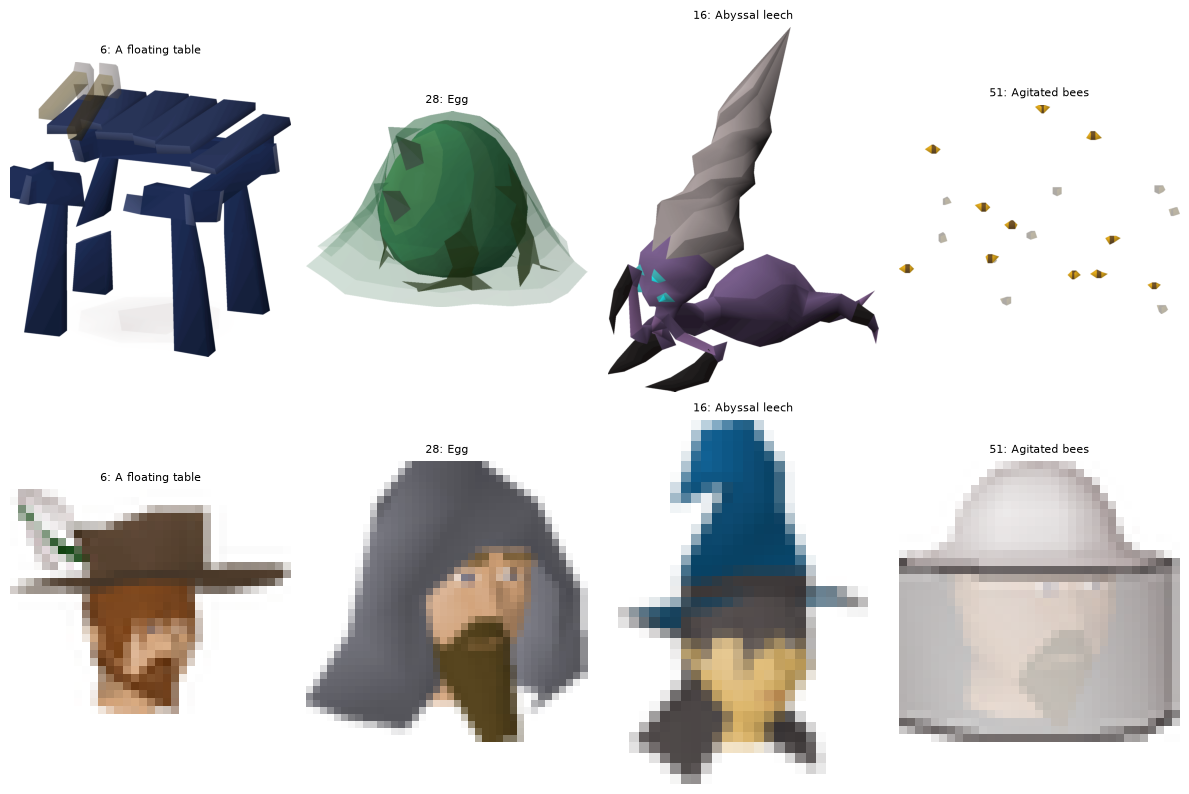

In [29]:
check_ids = [6, 28, 16, 51]

fig, axes = plt.subplots(2, len(check_ids), figsize=(len(check_ids) * 3, 8))
for col, npc_id in enumerate(check_ids):
    name = df.loc[df["id"] == npc_id, "Name"].values[0]
    for row, folder in enumerate(["bodies", "chatheads"]):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/{folder}/{npc_id}.png")
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.set_title(f"{npc_id}: {name}", fontsize=8)
        ax.set_ylabel(folder, fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

## Examples of 4 NPCs where everything is correct

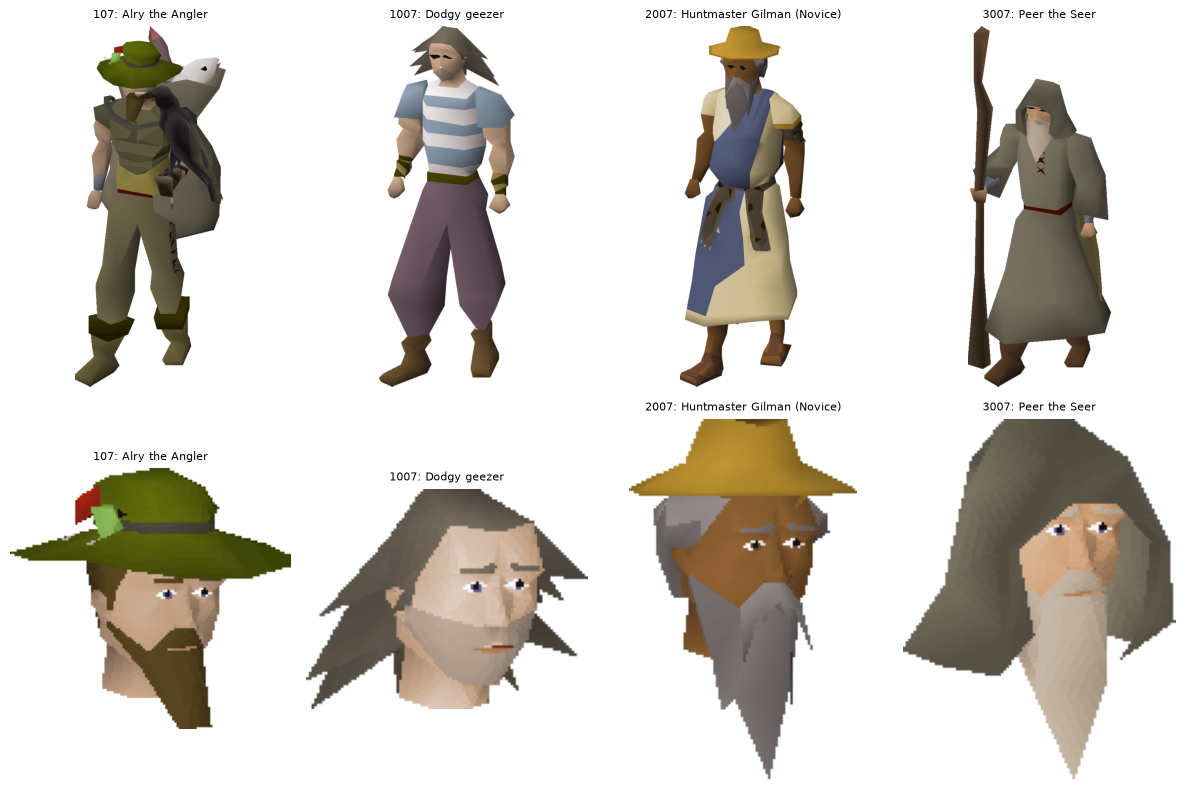

In [27]:
from IPython.display import display
import matplotlib.pyplot as plt

check_ids = [107, 1007, 2007, 3007]

fig, axes = plt.subplots(2, len(check_ids), figsize=(len(check_ids) * 3, 8))
for col, npc_id in enumerate(check_ids):
    name = df.loc[df["id"] == npc_id, "Name"].values[0]
    for row, folder in enumerate(["bodies", "chatheads"]):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/{folder}/{npc_id}.png")
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.set_title(f"{npc_id}: {name}", fontsize=8)
        ax.set_ylabel(folder, fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

## An observation

Notice how the "NPCs" in question are: an animated table, an egg, a monster, and a beeswarm. NPCs just in that they are moving and have interaction with the player, but not really "characters" in the traditional sense.

Might be worth limiting our data to just NPCs who we can talk to. We scraped `Options` from the infobox, so we could use those to filter our analysis. We'd just look for NPCs that have Talk-to.

In [30]:
df["Options"].value_counts().head(20)

Options
Talk-to                                          1895
Talk-to, Trade                                    374
Talk-to, Pickpocket                               116
Talk-to, Bank, Collect                             45
Take                                               40
Harvest                                            39
Talk-to, Pick-up                                   36
Talk-to, Pay, Trade                                33
Talk-to, Travel                                    30
Attack                                             25
Talk-To                                            24
Pet                                                23
Talk-to, Metamorphosis, Pick-up                    20
Catch                                              15
Talk-to, Trade, Customise-boat, Retrieve-boat      13
Talk-to, Assignment, Trade, Rewards                13
Retrieve                                           13
Talk-to, Escort, Supply                            12
Talk-to, Check-Appro